# 20 — Assembly101 Video-Only Students with Learnable Text Embeddings

This notebook tests a more direct use of action text than logit-only
knowledge distillation. The MS-TCN student learns an auxiliary mapping
from its temporal video representation to the CLIP action-text space.

Two controlled strategies are compared:

1. **fixed CLIP prototypes** — the student aligns video features to the
   frozen CLIP embedding of every action label;
2. **learnable CLIP prototypes** — every prototype starts from the same
   CLIP embedding and learns a regularized residual adaptation.

The segmentation path receives **video only**. Text is used only by an
auxiliary training loss. Validation, test, and deployment call
`student(video)` and do not read ground-truth text, a text encoder, or
a per-frame text input.

The design is inspired by CLIP-style metric classification and by the
idea of learning continuous text-side representations in CoOp, but it is
deliberately a small controlled extension of notebook 19 rather than a
reproduction of CoOp.

References:

- [CLIP: Learning Transferable Visual Models From Natural Language
  Supervision](https://proceedings.mlr.press/v139/radford21a.html)
- [CoOp: Learning to Prompt for Vision-Language
  Models](https://arxiv.org/abs/2109.01134)


## Experimental protocol

| Component | Choice |
|---|---|
| Dataset / split | Assembly101, the same official train/validation/test split as notebooks 16–19 |
| Video representation | CLIP ViT-B/16 features, shape `512 × 16` |
| Temporal model | The same four-stage MS-TCN student as notebook 19 |
| Text source | CLIP embeddings of the 202 action names |
| Text objective | Frame-to-prototype contrastive cross-entropy |
| Prototype variants | frozen CLIP vs. learnable residual CLIP prototypes |
| Model selection | validation `F1@25 + 0.01 × Edit` only |
| Test policy | evaluate only the validation-selected text strategy |
| Inference input | video only |

## 1. Mount Google Drive


In [1]:
from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


## 2. Imports, paths, and configuration


In [2]:
from pathlib import Path
from datetime import datetime, timezone

import gc
import hashlib
import json
import math
import random
import time
import traceback

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_colwidth", 240)

DRIVE_ROOT = Path("/content/drive/MyDrive/mmf_tas_lab_data")
FEATURE_ROOT = (
    DRIVE_ROOT
    / "text_assisted_tas"
    / "assembly101"
    / "coarse_mstcn_format"
    / "streaming_visual_features_v1"
)
DATA_ROOT = FEATURE_ROOT / "clip_vitb16"

NOTEBOOK18_SUMMARY = (
    FEATURE_ROOT
    / "runs"
    / "18_text_assisted_concat_teachers"
    / "final_summary_full.json"
)
NOTEBOOK19_ROOT = FEATURE_ROOT / "runs" / "19_video_only_kd_students"
NOTEBOOK19_SUMMARY = NOTEBOOK19_ROOT / "full" / "final_summary.json"
NOTEBOOK19_SHARED_INIT = (
    NOTEBOOK19_ROOT / "full" / "shared_student_initialization.pt"
)

OUT_ROOT = FEATURE_ROOT / "runs" / "20_learnable_text_students"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

RUN_MODE = "full"
# RUN_MODE = "smoke"

SEED = 7
RUN_CONFIGS = {
    "smoke": {
        "epochs": 3,
        "max_train_sequences": 64,
        "max_val_sequences": 32,
        "max_test_sequences": 32,
        "eval_every": 1,
        "patience_evals": None,
        "text_betas": [0.05],
        "prototype_modes": ["fixed", "learnable"],
    },
    "full": {
        "epochs": 120,
        "max_train_sequences": None,
        "max_val_sequences": None,
        "max_test_sequences": None,
        "eval_every": 5,
        "patience_evals": 12,
        "text_betas": [0.01, 0.05, 0.10],
        "prototype_modes": ["fixed", "learnable"],
    },
}

if RUN_MODE not in RUN_CONFIGS:
    raise ValueError(f"Unknown RUN_MODE: {RUN_MODE}")

CFG = RUN_CONFIGS[RUN_MODE]

EXPECTED_VIDEO_DIM = 512
EXPECTED_TEXT_DIM = 512
EXPECTED_TEMPORAL_LENGTH = 16
EXPECTED_NUM_CLASSES = 202

NUM_STAGES = 4
NUM_LAYERS = 6
NUM_F_MAPS = 64
DROPOUT = 0.5

BATCH_SIZE = 64
NUM_WORKERS = 0
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 5.0

SMOOTHING_WEIGHT = 0.15
SMOOTHING_CLIP_VALUE = 16.0

TEXT_BETAS = list(CFG["text_betas"])
PROTOTYPE_MODES = list(CFG["prototype_modes"])
INITIAL_TEXT_TEMPERATURE = 0.07
LEARNABLE_RESIDUAL_SCALE = 0.10
PROTOTYPE_ANCHOR_WEIGHT = 0.01

RESUME_IF_AVAILABLE = True
FORCE_RETRAIN_COMPLETED = False
FORCE_RECREATE_SHARED_INITIALIZATION = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("RUN_MODE:", RUN_MODE)
print("CFG:", CFG)
print("TEXT_BETAS:", TEXT_BETAS)
print("PROTOTYPE_MODES:", PROTOTYPE_MODES)
print("DEVICE:", DEVICE)
print("OUT_ROOT:", OUT_ROOT)

if RUN_MODE == "full" and not torch.cuda.is_available():
    print("WARNING: full training is running without a GPU.")


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
RUN_MODE: full
CFG: {'epochs': 120, 'max_train_sequences': None, 'max_val_sequences': None, 'max_test_sequences': None, 'eval_every': 5, 'patience_evals': 12, 'text_betas': [0.01, 0.05, 0.1], 'prototype_modes': ['fixed', 'learnable']}
TEXT_BETAS: [0.01, 0.05, 0.1]
PROTOTYPE_MODES: ['fixed', 'learnable']
DEVICE: cuda
OUT_ROOT: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/20_learnable_text_students


## 3. Resolve completed notebook 18/19 artifacts


In [3]:
for name, path in {
    "CLIP feature dataset": DATA_ROOT,
    "notebook 18 summary": NOTEBOOK18_SUMMARY,
    "notebook 19 summary": NOTEBOOK19_SUMMARY,
    "notebook 19 shared initialization": NOTEBOOK19_SHARED_INIT,
}.items():
    print(f"{name}: {path} -> {path.exists()}")
    if not path.exists():
        raise FileNotFoundError(f"Missing prerequisite: {name}: {path}")

notebook18 = json.loads(NOTEBOOK18_SUMMARY.read_text(encoding="utf-8"))
notebook19 = json.loads(NOTEBOOK19_SUMMARY.read_text(encoding="utf-8"))

if notebook18.get("status") != "completed":
    raise RuntimeError("Notebook 18 is not marked completed.")
if notebook19.get("status") != "completed":
    raise RuntimeError("Notebook 19 is not marked completed.")

teacher_key = "mstcn/clip_vitb16"
teacher_experiment = notebook18["experiments"][teacher_key]

TEXT_EMBEDDING_PATH = Path(
    teacher_experiment["input"]["text_embedding_path"]
)
TEXT_METADATA_PATH = Path(
    teacher_experiment["input"]["text_metadata_path"]
)
TRAIN_VIDEO_MEAN_PATH = Path(
    teacher_experiment["paths"]["train_video_mean"]
)
TRAIN_VIDEO_STD_PATH = Path(
    teacher_experiment["paths"]["train_video_std"]
)

for name, path in {
    "CLIP action-text embeddings": TEXT_EMBEDDING_PATH,
    "CLIP action-text metadata": TEXT_METADATA_PATH,
    "train video mean": TRAIN_VIDEO_MEAN_PATH,
    "train video std": TRAIN_VIDEO_STD_PATH,
}.items():
    print(f"{name}: {path} -> {path.exists()}")
    if not path.exists():
        raise FileNotFoundError(f"Missing artifact: {name}: {path}")

print(
    json.dumps(
        {
            "notebook19_selected_kd_lambda": notebook19["selected_kd_lambda"],
            "notebook19_controlled_ce_test": notebook19["controlled_ce"]["test"]["metrics"],
            "notebook19_selected_kd_test": notebook19["selected_kd_student"]["test"]["metrics"],
            "new_experiment_teacher_required": False,
            "new_experiment_inference_input": "video only",
        },
        indent=2,
    )
)


CLIP feature dataset: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/clip_vitb16 -> True
notebook 18 summary: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/18_text_assisted_concat_teachers/final_summary_full.json -> True
notebook 19 summary: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/19_video_only_kd_students/full/final_summary.json -> True
notebook 19 shared initialization: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/19_video_only_kd_students/full/shared_student_initialization.pt -> True
CLIP action-text embeddings: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/clip_vitb16/text_embeddings/assembly101_coarse_

## 4. Reproducibility, mapping, and official split


In [4]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def read_nonempty_lines(path):
    return [
        line.strip()
        for line in Path(path).read_text(
            encoding="utf-8", errors="replace"
        ).splitlines()
        if line.strip()
    ]


def load_mapping(path):
    id_to_label = {}
    label_to_id = {}
    for line in read_nonempty_lines(path):
        class_id_text, label = line.split(maxsplit=1)
        class_id = int(class_id_text)
        if class_id in id_to_label:
            raise ValueError(f"Duplicate class ID: {class_id}")
        if label in label_to_id:
            raise ValueError(f"Duplicate label: {label}")
        id_to_label[class_id] = label
        label_to_id[label] = class_id
    return id_to_label, label_to_id


def resolve_bundle(split_dir, split_name):
    split_dir = Path(split_dir)
    for candidate in [
        split_dir / f"{split_name}.bundle",
        split_dir / f"{split_name}.split1.bundle",
    ]:
        if candidate.exists():
            return candidate
    candidates = sorted(
        path
        for path in split_dir.glob("*.bundle")
        if split_name.lower() in path.name.lower()
        and ".partial." not in path.name.lower()
        and not path.name.lower().endswith(".partial.bundle")
    )
    if len(candidates) != 1:
        raise FileNotFoundError(
            f"Could not uniquely resolve {split_name}: {candidates}"
        )
    return candidates[0]


def read_bundle(path):
    sequence_ids = [Path(line).stem for line in read_nonempty_lines(path)]
    if len(sequence_ids) != len(set(sequence_ids)):
        raise ValueError(f"Duplicate IDs in {path}")
    return sequence_ids


def limit_ids(sequence_ids, maximum):
    if maximum is None:
        return list(sequence_ids)
    return list(sequence_ids)[: int(maximum)]


set_seed(SEED)

MAPPING_PATH = DATA_ROOT / "mapping.txt"
SPLIT_DIR = DATA_ROOT / "splits"
id_to_label, label_to_id = load_mapping(MAPPING_PATH)
num_classes = len(id_to_label)

if num_classes != EXPECTED_NUM_CLASSES:
    raise ValueError(
        f"Expected {EXPECTED_NUM_CLASSES} classes, found {num_classes}"
    )
if set(id_to_label) != set(range(num_classes)):
    raise ValueError("Class IDs must be contiguous from 0 to 201.")

train_ids_full = read_bundle(resolve_bundle(SPLIT_DIR, "train"))
val_ids_full = read_bundle(resolve_bundle(SPLIT_DIR, "val"))
test_ids_full = read_bundle(resolve_bundle(SPLIT_DIR, "test"))

assert set(train_ids_full).isdisjoint(set(val_ids_full))
assert set(train_ids_full).isdisjoint(set(test_ids_full))
assert set(val_ids_full).isdisjoint(set(test_ids_full))
assert len(set(train_ids_full) | set(val_ids_full) | set(test_ids_full)) == 680

train_ids = limit_ids(train_ids_full, CFG["max_train_sequences"])
val_ids = limit_ids(val_ids_full, CFG["max_val_sequences"])
test_ids = limit_ids(test_ids_full, CFG["max_test_sequences"])

print("Classes:", num_classes)
print("Train:", len(train_ids))
print("Validation:", len(val_ids))
print("Test reserved:", len(test_ids))


Classes: 202
Train: 393
Validation: 120
Test reserved: 167


## 5. Text bank, train-only normalization, dataset, and loaders


In [5]:
text_embeddings = np.load(TEXT_EMBEDDING_PATH).astype(np.float32)
text_metadata = pd.read_csv(TEXT_METADATA_PATH)

required_columns = {"model_class_id", "action_cls", "prompt", "clip_model"}
missing_columns = required_columns - set(text_metadata.columns)
if missing_columns:
    raise KeyError(f"Missing text metadata columns: {sorted(missing_columns)}")

if text_embeddings.shape != (EXPECTED_NUM_CLASSES, EXPECTED_TEXT_DIM):
    raise ValueError(f"Unexpected text shape: {text_embeddings.shape}")

text_metadata = text_metadata.sort_values("model_class_id").reset_index(drop=True)
if not np.array_equal(
    text_metadata["model_class_id"].to_numpy(),
    np.arange(EXPECTED_NUM_CLASSES),
):
    raise ValueError("Text metadata does not cover IDs 0..201 exactly.")

for class_id in range(num_classes):
    action_name = str(text_metadata.loc[class_id, "action_cls"])
    if action_name != str(id_to_label[class_id]):
        raise ValueError(
            f"Text/mapping mismatch at {class_id}: "
            f"{action_name} != {id_to_label[class_id]}"
        )

text_embeddings /= np.maximum(
    np.linalg.norm(text_embeddings, axis=1, keepdims=True),
    1e-12,
)
text_embeddings = text_embeddings.astype(np.float32)
text_bank_tensor = torch.from_numpy(text_embeddings)

train_video_mean = np.load(TRAIN_VIDEO_MEAN_PATH).astype(np.float32)
train_video_std = np.load(TRAIN_VIDEO_STD_PATH).astype(np.float32)

if train_video_mean.shape != (EXPECTED_VIDEO_DIM,):
    raise ValueError(f"Unexpected mean shape: {train_video_mean.shape}")
if train_video_std.shape != (EXPECTED_VIDEO_DIM,):
    raise ValueError(f"Unexpected std shape: {train_video_std.shape}")
if np.any(train_video_std <= 0):
    raise ValueError("All train standard deviations must be positive.")


class Assembly101TextStudentDataset(Dataset):
    def __init__(self, sequence_ids):
        self.sequence_ids = list(sequence_ids)
        self.feature_dir = DATA_ROOT / "features"
        self.gt_dir = DATA_ROOT / "groundTruth"

    def __len__(self):
        return len(self.sequence_ids)

    def __getitem__(self, index):
        sequence_id = self.sequence_ids[index]
        video = np.load(
            self.feature_dir / f"{sequence_id}.npy"
        ).astype(np.float32)
        label_names = read_nonempty_lines(
            self.gt_dir / f"{sequence_id}.txt"
        )
        labels = np.asarray(
            [label_to_id[label] for label in label_names],
            dtype=np.int64,
        )

        if video.shape != (EXPECTED_VIDEO_DIM, EXPECTED_TEMPORAL_LENGTH):
            raise ValueError(
                f"Unexpected video shape for {sequence_id}: {video.shape}"
            )
        if labels.shape != (EXPECTED_TEMPORAL_LENGTH,):
            raise ValueError(
                f"Unexpected labels for {sequence_id}: {labels.shape}"
            )
        if not np.isfinite(video).all():
            raise ValueError(f"Non-finite video values for {sequence_id}")

        video = (
            video - train_video_mean[:, None]
        ) / (
            train_video_std[:, None] + 1e-8
        )

        return {
            "sequence_id": sequence_id,
            "video": torch.from_numpy(video),
            "labels": torch.from_numpy(labels),
        }


train_dataset = Assembly101TextStudentDataset(train_ids)
val_dataset = Assembly101TextStudentDataset(val_ids)
test_dataset = Assembly101TextStudentDataset(test_ids)


def make_train_loader(epoch):
    generator = torch.Generator()
    generator.manual_seed(SEED + int(epoch))
    return DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        generator=generator,
    )


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

sample = next(iter(make_train_loader(1)))
assert sample["video"].shape[1:] == (
    EXPECTED_VIDEO_DIM,
    EXPECTED_TEMPORAL_LENGTH,
)
assert sample["labels"].shape[1:] == (EXPECTED_TEMPORAL_LENGTH,)

print("Text bank:", tuple(text_bank_tensor.shape))
print("Train/val/test:", len(train_dataset), len(val_dataset), len(test_dataset))
print("Video batch:", tuple(sample["video"].shape))
print("Label batch:", tuple(sample["labels"].shape))
print("Dataset returns per-frame text:", False)


Text bank: (202, 512)
Train/val/test: 393 120 167
Video batch: (64, 512, 16)
Label batch: (64, 16)
Dataset returns per-frame text: False


## 6. Temporal action segmentation metrics


In [6]:
IGNORE_CLASS_NAMES = {"background", "SIL", "silence"}
ignore_class_ids = {
    label_to_id[name]
    for name in IGNORE_CLASS_NAMES
    if name in label_to_id
}


def collapse_segments(frame_labels, ignored_ids=None):
    ignored_ids = set(ignored_ids or [])
    labels, starts, ends = [], [], []
    active = None
    for index, label in enumerate(frame_labels):
        label = int(label)
        if label in ignored_ids:
            if active is not None:
                ends.append(index)
                active = None
            continue
        if label != active:
            if active is not None:
                ends.append(index)
            labels.append(label)
            starts.append(index)
            active = label
    if active is not None:
        ends.append(len(frame_labels))
    return labels, starts, ends


def levenshtein_distance(predicted, target):
    distance = np.zeros(
        (len(predicted) + 1, len(target) + 1), dtype=np.int32
    )
    distance[:, 0] = np.arange(len(predicted) + 1)
    distance[0, :] = np.arange(len(target) + 1)
    for row in range(1, len(predicted) + 1):
        for column in range(1, len(target) + 1):
            substitution = int(predicted[row - 1] != target[column - 1])
            distance[row, column] = min(
                distance[row - 1, column] + 1,
                distance[row, column - 1] + 1,
                distance[row - 1, column - 1] + substitution,
            )
    return int(distance[-1, -1])


def edit_score_single(prediction, target, ignored_ids=None):
    predicted_segments, _, _ = collapse_segments(prediction, ignored_ids)
    target_segments, _, _ = collapse_segments(target, ignored_ids)
    if not predicted_segments and not target_segments:
        return 100.0
    denominator = max(len(predicted_segments), len(target_segments))
    if denominator == 0:
        return 0.0
    distance = levenshtein_distance(predicted_segments, target_segments)
    return (1.0 - distance / denominator) * 100.0


def f_score_single(prediction, target, overlap, ignored_ids=None):
    predicted_labels, predicted_starts, predicted_ends = collapse_segments(
        prediction, ignored_ids
    )
    target_labels, target_starts, target_ends = collapse_segments(
        target, ignored_ids
    )
    true_positives = 0
    false_positives = 0
    hits = np.zeros(len(target_labels), dtype=np.float32)

    for predicted_index in range(len(predicted_labels)):
        best_iou = 0.0
        best_target = -1
        for target_index in range(len(target_labels)):
            if predicted_labels[predicted_index] != target_labels[target_index]:
                continue
            intersection = (
                min(predicted_ends[predicted_index], target_ends[target_index])
                - max(predicted_starts[predicted_index], target_starts[target_index])
            )
            union = (
                max(predicted_ends[predicted_index], target_ends[target_index])
                - min(predicted_starts[predicted_index], target_starts[target_index])
            )
            iou = max(intersection, 0) / union if union > 0 else 0.0
            if iou > best_iou:
                best_iou = iou
                best_target = target_index
        if best_iou >= overlap and best_target >= 0 and hits[best_target] == 0:
            true_positives += 1
            hits[best_target] = 1
        else:
            false_positives += 1

    false_negatives = len(target_labels) - int(hits.sum())
    return true_positives, false_positives, false_negatives


def compute_metrics(predictions, targets, ignored_ids=None):
    total_correct = 0
    total_positions = 0
    edit_scores = []
    f_statistics = {
        0.10: [0, 0, 0],
        0.25: [0, 0, 0],
        0.50: [0, 0, 0],
    }
    for sequence_id, prediction in predictions.items():
        target = targets[sequence_id]
        total_correct += int((prediction == target).sum())
        total_positions += len(target)
        edit_scores.append(edit_score_single(prediction, target, ignored_ids))
        for overlap in f_statistics:
            tp, fp, fn = f_score_single(
                prediction, target, overlap, ignored_ids
            )
            f_statistics[overlap][0] += tp
            f_statistics[overlap][1] += fp
            f_statistics[overlap][2] += fn

    metrics = {
        "acc": 100.0 * total_correct / max(total_positions, 1),
        "edit": float(np.mean(edit_scores)) if edit_scores else 0.0,
    }
    for overlap, (tp, fp, fn) in f_statistics.items():
        precision = tp / max(tp + fp, 1e-8)
        recall = tp / max(tp + fn, 1e-8)
        f1 = 2.0 * precision * recall / max(precision + recall, 1e-8)
        metrics[f"f1@{int(overlap * 100)}"] = 100.0 * f1
    return metrics


def round_metrics(metrics):
    return {key: round(float(value), 2) for key, value in metrics.items()}


def selection_score(metrics):
    return float(metrics["f1@25"]) + 0.01 * float(metrics["edit"])


print("Ignored class IDs:", ignore_class_ids)
print("Metrics ready.")


Ignored class IDs: set()
Metrics ready.


## 7. MS-TCN student with an auxiliary learnable text space


In [7]:
class DilatedResidualLayer(nn.Module):
    def __init__(self, dilation, channels, dropout):
        super().__init__()
        self.conv_dilated = nn.Conv1d(
            channels,
            channels,
            kernel_size=3,
            padding=dilation,
            dilation=dilation,
        )
        self.conv_1x1 = nn.Conv1d(channels, channels, kernel_size=1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, inputs):
        output = F.relu(self.conv_dilated(inputs))
        output = self.conv_1x1(output)
        output = self.dropout(output)
        return inputs + output


class SingleStage(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.input_projection = nn.Conv1d(
            input_dim, NUM_F_MAPS, kernel_size=1
        )
        self.layers = nn.ModuleList(
            [
                DilatedResidualLayer(
                    dilation=2 ** layer_index,
                    channels=NUM_F_MAPS,
                    dropout=DROPOUT,
                )
                for layer_index in range(NUM_LAYERS)
            ]
        )
        self.output_projection = nn.Conv1d(
            NUM_F_MAPS, num_classes, kernel_size=1
        )

    def forward(self, inputs, return_hidden=False):
        hidden = self.input_projection(inputs)
        for layer in self.layers:
            hidden = layer(hidden)
        logits = self.output_projection(hidden)
        if return_hidden:
            return logits, hidden
        return logits


class MSTCNTextEmbeddingStudent(nn.Module):
    def __init__(self, num_classes, clip_text_bank, prototype_mode):
        super().__init__()
        if prototype_mode not in {"fixed", "learnable"}:
            raise ValueError(f"Unknown prototype mode: {prototype_mode}")

        self.prototype_mode = prototype_mode
        self.stage1 = SingleStage(EXPECTED_VIDEO_DIM, num_classes)
        self.refinement_stages = nn.ModuleList(
            [
                SingleStage(num_classes, num_classes)
                for _ in range(NUM_STAGES - 1)
            ]
        )

        self.video_to_text = nn.Conv1d(
            NUM_F_MAPS, EXPECTED_TEXT_DIM, kernel_size=1
        )
        self.register_buffer(
            "clip_text_bank",
            F.normalize(clip_text_bank.float().clone(), dim=-1),
        )
        self.prototype_delta = nn.Parameter(
            torch.zeros_like(self.clip_text_bank),
            requires_grad=(prototype_mode == "learnable"),
        )
        self.logit_scale = nn.Parameter(
            torch.tensor(math.log(1.0 / INITIAL_TEXT_TEMPERATURE))
        )

    def adapted_prototypes(self):
        prototypes = (
            self.clip_text_bank
            + LEARNABLE_RESIDUAL_SCALE * self.prototype_delta
        )
        return F.normalize(prototypes, dim=-1)

    def forward(self, video, return_text_aux=False):
        logits, hidden = self.stage1(video, return_hidden=True)
        outputs = [logits]
        for stage in self.refinement_stages:
            logits = stage(F.softmax(logits, dim=1))
            outputs.append(logits)
        stacked_outputs = torch.stack(outputs, dim=0)

        if not return_text_aux:
            return stacked_outputs

        projected_video = F.normalize(
            self.video_to_text(hidden), dim=1
        )
        auxiliary = {
            "projected_video": projected_video,
            "prototypes": self.adapted_prototypes(),
            "logit_scale": self.logit_scale.exp().clamp(max=100.0),
        }
        return stacked_outputs, auxiliary


def create_student(prototype_mode):
    return MSTCNTextEmbeddingStudent(
        num_classes=num_classes,
        clip_text_bank=text_bank_tensor,
        prototype_mode=prototype_mode,
    ).to(DEVICE)


for mode in PROTOTYPE_MODES:
    shape_test = create_student(mode)
    with torch.no_grad():
        dummy_video = torch.zeros(
            2,
            EXPECTED_VIDEO_DIM,
            EXPECTED_TEMPORAL_LENGTH,
            device=DEVICE,
        )
        outputs = shape_test(dummy_video)
        outputs_aux, auxiliary = shape_test(
            dummy_video, return_text_aux=True
        )

    expected_output_shape = (
        NUM_STAGES,
        2,
        num_classes,
        EXPECTED_TEMPORAL_LENGTH,
    )
    assert outputs.shape == expected_output_shape
    assert outputs_aux.shape == expected_output_shape
    assert auxiliary["projected_video"].shape == (
        2,
        EXPECTED_TEXT_DIM,
        EXPECTED_TEMPORAL_LENGTH,
    )
    assert auxiliary["prototypes"].shape == (
        num_classes,
        EXPECTED_TEXT_DIM,
    )

    print(
        mode,
        "parameters=",
        sum(parameter.numel() for parameter in shape_test.parameters()),
        "trainable=",
        sum(
            parameter.numel()
            for parameter in shape_test.parameters()
            if parameter.requires_grad
        ),
    )
    del shape_test, dummy_video, outputs, outputs_aux, auxiliary

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Inference signature: student(video)")
print("Text auxiliary signature: student(video, return_text_aux=True)")


fixed parameters= 657321 trainable= 553897
learnable parameters= 657321 trainable= 657321
Inference signature: student(video)
Text auxiliary signature: student(video, return_text_aux=True)


## 8. Segmentation and text-alignment losses


In [8]:
def supervised_loss(outputs, targets):
    total = torch.zeros((), device=outputs.device)
    ce_sum = 0.0
    smooth_sum = 0.0

    for stage_index in range(outputs.shape[0]):
        logits = outputs[stage_index]
        ce = F.cross_entropy(
            logits.permute(0, 2, 1).reshape(-1, logits.shape[1]),
            targets.reshape(-1),
        )
        log_probabilities = F.log_softmax(logits, dim=1)
        smooth = F.mse_loss(
            log_probabilities[:, :, 1:],
            log_probabilities.detach()[:, :, :-1],
            reduction="none",
        )
        smooth = torch.clamp(
            smooth, min=0.0, max=SMOOTHING_CLIP_VALUE
        ).mean()
        total = total + ce + SMOOTHING_WEIGHT * smooth
        ce_sum += float(ce.detach().cpu())
        smooth_sum += float(smooth.detach().cpu())

    return total, {
        "segmentation": float(total.detach().cpu()),
        "cross_entropy_sum": ce_sum,
        "smoothing_sum": smooth_sum,
    }


def text_alignment_loss(auxiliary, targets):
    projected_video = auxiliary["projected_video"]
    prototypes = auxiliary["prototypes"]
    logit_scale = auxiliary["logit_scale"]

    similarity_logits = logit_scale * torch.einsum(
        "bdt,cd->bct", projected_video, prototypes
    )
    contrastive_ce = F.cross_entropy(
        similarity_logits.permute(0, 2, 1).reshape(-1, num_classes),
        targets.reshape(-1),
    )

    return contrastive_ce, similarity_logits


def prototype_anchor_loss(model):
    if model.prototype_mode != "learnable":
        return torch.zeros((), device=DEVICE)
    adapted = model.adapted_prototypes()
    original = model.clip_text_bank
    return (1.0 - (adapted * original).sum(dim=-1)).mean()


def total_loss(model, outputs, auxiliary, targets, text_beta):
    segmentation, segmentation_parts = supervised_loss(outputs, targets)
    text_loss, _ = text_alignment_loss(auxiliary, targets)
    anchor = prototype_anchor_loss(model)
    total = (
        segmentation
        + float(text_beta) * text_loss
        + PROTOTYPE_ANCHOR_WEIGHT * anchor
    )
    return total, {
        **segmentation_parts,
        "text_unweighted": float(text_loss.detach().cpu()),
        "text_weighted": float(
            (float(text_beta) * text_loss).detach().cpu()
        ),
        "prototype_anchor": float(anchor.detach().cpu()),
        "prototype_anchor_weighted": float(
            (PROTOTYPE_ANCHOR_WEIGHT * anchor).detach().cpu()
        ),
        "total": float(total.detach().cpu()),
    }


print("L_total = L_seg + beta_text * L_text + gamma_anchor * L_anchor")
print("L_text: frame-to-class-prototype contrastive cross-entropy")
print("gamma_anchor:", PROTOTYPE_ANCHOR_WEIGHT)
print("No teacher logits are used in notebook 20.")


L_total = L_seg + beta_text * L_text + gamma_anchor * L_anchor
L_text: frame-to-class-prototype contrastive cross-entropy
gamma_anchor: 0.01
No teacher logits are used in notebook 20.


## 9. Common initialization and video-only evaluation


In [9]:
def load_checkpoint(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def fingerprint(state_dict):
    digest = hashlib.sha256()
    for key in sorted(state_dict):
        tensor = state_dict[key].detach().cpu().contiguous()
        digest.update(key.encode("utf-8"))
        digest.update(tensor.numpy().tobytes())
    return digest.hexdigest()


notebook19_shared = load_checkpoint(NOTEBOOK19_SHARED_INIT)
notebook19_backbone_state = notebook19_shared["model_state_dict"]

SHARED_TEXT_INIT_PATH = (
    OUT_ROOT / RUN_MODE / "shared_text_student_initialization.pt"
)
SHARED_TEXT_INIT_PATH.parent.mkdir(parents=True, exist_ok=True)

shared_config = {
    "seed": SEED,
    "num_stages": NUM_STAGES,
    "num_layers": NUM_LAYERS,
    "num_f_maps": NUM_F_MAPS,
    "dropout": DROPOUT,
    "video_dim": EXPECTED_VIDEO_DIM,
    "text_dim": EXPECTED_TEXT_DIM,
    "num_classes": num_classes,
    "residual_scale": LEARNABLE_RESIDUAL_SCALE,
}

if SHARED_TEXT_INIT_PATH.exists() and not FORCE_RECREATE_SHARED_INITIALIZATION:
    shared_payload = load_checkpoint(SHARED_TEXT_INIT_PATH)
    if shared_payload.get("config") != shared_config:
        raise ValueError(
            "Existing shared text initialization is incompatible. "
            "Set FORCE_RECREATE_SHARED_INITIALIZATION=True."
        )
    shared_state = shared_payload["model_state_dict"]
else:
    set_seed(SEED)
    initial_model = create_student("learnable")
    incompatible = initial_model.load_state_dict(
        notebook19_backbone_state, strict=False
    )

    expected_missing = {
        "clip_text_bank",
        "prototype_delta",
        "logit_scale",
        "video_to_text.weight",
        "video_to_text.bias",
    }
    if set(incompatible.missing_keys) != expected_missing:
        raise RuntimeError(
            f"Unexpected missing initialization keys: {incompatible.missing_keys}"
        )
    if incompatible.unexpected_keys:
        raise RuntimeError(
            f"Unexpected notebook 19 keys: {incompatible.unexpected_keys}"
        )

    shared_state = {
        key: value.detach().cpu().clone()
        for key, value in initial_model.state_dict().items()
    }
    torch.save(
        {
            "config": shared_config,
            "source_backbone": str(NOTEBOOK19_SHARED_INIT),
            "model_state_dict": shared_state,
            "fingerprint": fingerprint(shared_state),
        },
        SHARED_TEXT_INIT_PATH,
    )
    del initial_model
    gc.collect()

shared_fingerprint = fingerprint(shared_state)


@torch.no_grad()
def evaluate_student(
    model,
    loader,
    save_predictions=False,
    prediction_dir=None,
):
    model.eval()
    predictions = {}
    targets = {}

    if save_predictions:
        prediction_dir = Path(prediction_dir)
        prediction_dir.mkdir(parents=True, exist_ok=True)

    for batch in loader:
        video = batch["video"].to(DEVICE, non_blocking=True)
        labels = batch["labels"].cpu().numpy()
        sequence_ids = list(batch["sequence_id"])

        # Intentionally video-only. The auxiliary text path is not called.
        outputs = model(video)
        predicted = outputs[-1].argmax(dim=1).detach().cpu().numpy()

        for index, sequence_id in enumerate(sequence_ids):
            pred_ids = predicted[index].astype(np.int64)
            target_ids = labels[index].astype(np.int64)
            predictions[sequence_id] = pred_ids
            targets[sequence_id] = target_ids

            if save_predictions:
                pred_labels = [id_to_label[int(value)] for value in pred_ids]
                (prediction_dir / f"{sequence_id}.txt").write_text(
                    "\n".join(pred_labels) + "\n",
                    encoding="utf-8",
                )

    return (
        compute_metrics(predictions, targets, ignore_class_ids),
        predictions,
        targets,
    )


print("Shared initialization:", SHARED_TEXT_INIT_PATH)
print("Fingerprint:", shared_fingerprint)
print("Backbone initialized from notebook 19:", NOTEBOOK19_SHARED_INIT)
print("Validation/test inference: student(video)")


Shared initialization: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/20_learnable_text_students/full/shared_text_student_initialization.pt
Fingerprint: a3db0b501cddbb5670c0cd3655b7004642323d8d74b981e5d72ac23ce448d1dc
Backbone initialized from notebook 19: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/19_video_only_kd_students/full/shared_student_initialization.pt
Validation/test inference: student(video)


## 10. Train one controlled text-embedding experiment


In [10]:
def value_name(value):
    return (
        f"{float(value):.4f}"
        .rstrip("0")
        .rstrip(".")
        .replace(".", "p")
    )


def experiment_name(prototype_mode, text_beta):
    return f"{prototype_mode}_clip_beta_{value_name(text_beta)}"


def train_experiment(prototype_mode, text_beta):
    text_beta = float(text_beta)
    name = experiment_name(prototype_mode, text_beta)
    experiment_root = OUT_ROOT / RUN_MODE / name
    model_dir = experiment_root / "models"
    result_dir = experiment_root / "results"
    model_dir.mkdir(parents=True, exist_ok=True)
    result_dir.mkdir(parents=True, exist_ok=True)

    best_path = model_dir / "best_student.pt"
    last_path = model_dir / "last_checkpoint.pt"
    history_path = result_dir / "training_history.csv"
    summary_path = result_dir / "validation_summary.json"

    if summary_path.exists() and not FORCE_RETRAIN_COMPLETED:
        previous = json.loads(summary_path.read_text(encoding="utf-8"))
        if previous.get("status") == "validation_complete":
            print("Skipping completed:", name)
            return previous

    set_seed(SEED)
    student = create_student(prototype_mode)
    student.load_state_dict(shared_state, strict=True)

    current_fingerprint = fingerprint(
        {
            key: value.detach().cpu()
            for key, value in student.state_dict().items()
        }
    )
    if current_fingerprint != shared_fingerprint:
        raise RuntimeError("Shared initialization did not load exactly.")

    optimizer = torch.optim.AdamW(
        [parameter for parameter in student.parameters() if parameter.requires_grad],
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CFG["epochs"]
    )

    start_epoch = 1
    best_score = -math.inf
    best_epoch = None
    best_validation_metrics = None
    no_improvement_evals = 0
    history = []

    if RESUME_IF_AVAILABLE and last_path.exists():
        checkpoint = load_checkpoint(last_path)
        compatible = (
            checkpoint.get("run_mode") == RUN_MODE
            and checkpoint.get("prototype_mode") == prototype_mode
            and float(checkpoint.get("text_beta")) == text_beta
            and checkpoint.get("initialization_fingerprint")
            == shared_fingerprint
        )
        if compatible:
            student.load_state_dict(
                checkpoint["model_state_dict"], strict=True
            )
            optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
            scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
            start_epoch = int(checkpoint["epoch"]) + 1
            best_score = float(checkpoint.get("best_score", -math.inf))
            best_epoch = checkpoint.get("best_epoch")
            best_validation_metrics = checkpoint.get(
                "best_validation_metrics"
            )
            no_improvement_evals = int(
                checkpoint.get("no_improvement_evals", 0)
            )
            history = list(checkpoint.get("history", []))
            print("Resuming", name, "from epoch", start_epoch)

    print("\n" + "=" * 88)
    print("EXPERIMENT:", name)
    print("Prototype mode:", prototype_mode)
    print("Text beta:", text_beta)
    print("Teacher used:", False)
    print("Validation/test input: video only")
    print("=" * 88)

    start_time = time.time()
    stopped_early = False

    for epoch in range(start_epoch, CFG["epochs"] + 1):
        student.train()
        train_loader = make_train_loader(epoch)

        total_values = []
        segmentation_values = []
        text_values = []
        anchor_values = []

        for batch in train_loader:
            video = batch["video"].to(DEVICE, non_blocking=True)
            labels = batch["labels"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            outputs, auxiliary = student(
                video, return_text_aux=True
            )
            loss, parts = total_loss(
                student, outputs, auxiliary, labels, text_beta
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), GRAD_CLIP)
            optimizer.step()

            total_values.append(parts["total"])
            segmentation_values.append(parts["segmentation"])
            text_values.append(parts["text_unweighted"])
            anchor_values.append(parts["prototype_anchor"])

        scheduler.step()

        row = {
            "experiment": name,
            "prototype_mode": prototype_mode,
            "text_beta": text_beta,
            "epoch": epoch,
            "train_total_loss": float(np.mean(total_values)),
            "train_segmentation_loss": float(np.mean(segmentation_values)),
            "train_text_loss": float(np.mean(text_values)),
            "train_prototype_anchor": float(np.mean(anchor_values)),
            "learning_rate": float(scheduler.get_last_lr()[0]),
        }

        evaluate_now = (
            epoch == 1
            or epoch % CFG["eval_every"] == 0
            or epoch == CFG["epochs"]
        )

        if evaluate_now:
            validation_metrics, _, _ = evaluate_student(
                student, val_loader
            )
            row.update(
                {
                    f"val_{key}": value
                    for key, value in validation_metrics.items()
                }
            )
            score = selection_score(validation_metrics)
            improved = score > best_score

            if improved:
                best_score = score
                best_epoch = epoch
                best_validation_metrics = dict(validation_metrics)
                no_improvement_evals = 0
                torch.save(
                    {
                        "epoch": epoch,
                        "run_mode": RUN_MODE,
                        "experiment": name,
                        "prototype_mode": prototype_mode,
                        "text_beta": text_beta,
                        "student_input": "video only",
                        "student_deployable": True,
                        "text_auxiliary_enabled_at_inference": False,
                        "initialization_fingerprint": shared_fingerprint,
                        "model_state_dict": student.state_dict(),
                        "validation_metrics": validation_metrics,
                        "selection_score": score,
                        "model_config": shared_config,
                    },
                    best_path,
                )
            else:
                no_improvement_evals += 1

            print(
                f"{name} epoch {epoch:03d} "
                f"total={row['train_total_loss']:.4f} "
                f"seg={row['train_segmentation_loss']:.4f} "
                f"text={row['train_text_loss']:.4f} "
                f"val_acc={validation_metrics['acc']:.2f} "
                f"val_edit={validation_metrics['edit']:.2f} "
                f"val_f1@25={validation_metrics['f1@25']:.2f} "
                f"val_f1@50={validation_metrics['f1@50']:.2f} "
                f"best={'yes' if improved else 'no'}"
            )
        else:
            print(
                f"{name} epoch {epoch:03d} "
                f"total={row['train_total_loss']:.4f} "
                f"seg={row['train_segmentation_loss']:.4f} "
                f"text={row['train_text_loss']:.4f}"
            )

        history.append(row)
        torch.save(
            {
                "epoch": epoch,
                "run_mode": RUN_MODE,
                "experiment": name,
                "prototype_mode": prototype_mode,
                "text_beta": text_beta,
                "initialization_fingerprint": shared_fingerprint,
                "model_state_dict": student.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_score": best_score,
                "best_epoch": best_epoch,
                "best_validation_metrics": best_validation_metrics,
                "no_improvement_evals": no_improvement_evals,
                "history": history,
            },
            last_path,
        )
        pd.DataFrame(history).to_csv(history_path, index=False)

        patience = CFG["patience_evals"]
        if (
            evaluate_now
            and patience is not None
            and no_improvement_evals >= patience
        ):
            stopped_early = True
            print(
                "Early stopping after",
                no_improvement_evals,
                "validation evaluations without improvement.",
            )
            break

    if not best_path.exists():
        raise RuntimeError(f"No best checkpoint saved for {name}")

    best_checkpoint = load_checkpoint(best_path)
    summary = {
        "status": "validation_complete",
        "run_mode": RUN_MODE,
        "experiment": name,
        "prototype_mode": prototype_mode,
        "text_beta": text_beta,
        "teacher_used_during_training": False,
        "student_training_input": (
            "video + labels; CLIP action embeddings are used by an "
            "auxiliary prototype loss"
        ),
        "student_validation_input": "video only",
        "student_test_input": "video only",
        "student_deployable": True,
        "initialization_fingerprint": shared_fingerprint,
        "training": {
            "maximum_epochs": CFG["epochs"],
            "best_epoch": int(best_checkpoint["epoch"]),
            "stopped_early": stopped_early,
            "minutes_this_run": (time.time() - start_time) / 60.0,
            "batch_size": BATCH_SIZE,
            "seed": SEED,
        },
        "best_validation_score": float(best_checkpoint["selection_score"]),
        "best_validation_metrics": round_metrics(
            best_checkpoint["validation_metrics"]
        ),
        "test_metrics": None,
        "paths": {
            "best_student": str(best_path),
            "last_checkpoint": str(last_path),
            "training_history": str(history_path),
        },
    }
    summary_path.write_text(
        json.dumps(summary, indent=2), encoding="utf-8"
    )

    print(
        json.dumps(
            {
                "experiment": name,
                "best_epoch": summary["training"]["best_epoch"],
                "best_validation_metrics": summary["best_validation_metrics"],
                "best_student": summary["paths"]["best_student"],
            },
            indent=2,
        )
    )

    del student, optimizer, scheduler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return summary


## 11. Run the fixed-versus-learnable prototype ablation


In [11]:
try:
    experiment_summaries = []
    for prototype_mode in PROTOTYPE_MODES:
        for text_beta in TEXT_BETAS:
            experiment_summaries.append(
                train_experiment(prototype_mode, text_beta)
            )
except Exception:
    error_dir = OUT_ROOT / RUN_MODE / "errors"
    error_dir.mkdir(parents=True, exist_ok=True)
    error_path = error_dir / "training_traceback.txt"
    error_path.write_text(traceback.format_exc(), encoding="utf-8")
    print("Saved traceback:", error_path)
    raise

print("Completed validation runs:", len(experiment_summaries))
for summary in experiment_summaries:
    print(
        summary["experiment"],
        summary["best_validation_metrics"],
    )



EXPERIMENT: fixed_clip_beta_0p01
Prototype mode: fixed
Text beta: 0.01
Teacher used: False
Validation/test input: video only
fixed_clip_beta_0p01 epoch 001 total=21.1946 seg=21.1416 text=5.3007 val_acc=11.67 val_edit=3.09 val_f1@25=4.49 val_f1@50=0.56 best=yes
fixed_clip_beta_0p01 epoch 002 total=20.3050 seg=20.2531 text=5.1882
fixed_clip_beta_0p01 epoch 003 total=18.9873 seg=18.9371 text=5.0193
fixed_clip_beta_0p01 epoch 004 total=17.8894 seg=17.8410 text=4.8375
fixed_clip_beta_0p01 epoch 005 total=17.2506 seg=17.2035 text=4.7136 val_acc=10.57 val_edit=5.02 val_f1@25=4.05 val_f1@50=0.17 best=no
fixed_clip_beta_0p01 epoch 006 total=16.7277 seg=16.6814 text=4.6275
fixed_clip_beta_0p01 epoch 007 total=16.6221 seg=16.5763 text=4.5865
fixed_clip_beta_0p01 epoch 008 total=16.2590 seg=16.2139 text=4.5080
fixed_clip_beta_0p01 epoch 009 total=16.1077 seg=16.0630 text=4.4695
fixed_clip_beta_0p01 epoch 010 total=15.9912 seg=15.9468 text=4.4387 val_acc=13.91 val_edit=5.87 val_f1@25=7.42 val_f1@5

## 12. Select the strategy and weight using validation only


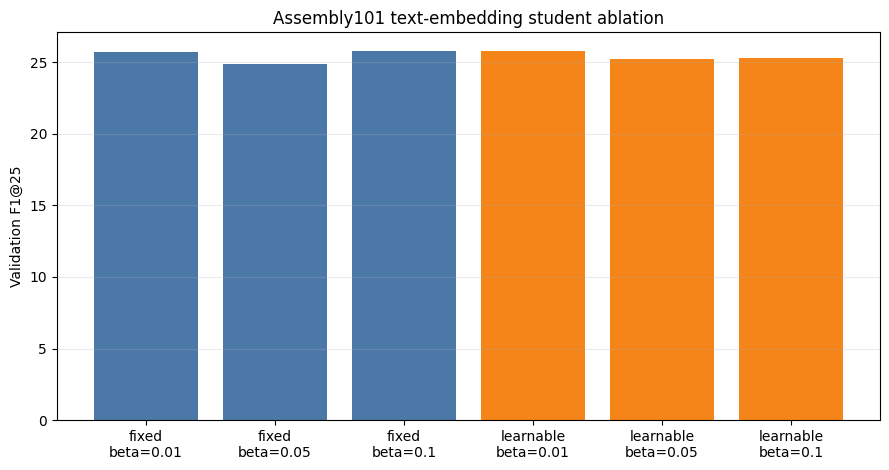

,experiment,strategy,text_beta,best_epoch,val_acc,val_edit,val_f1@10,val_f1@25,val_f1@50,selection_score,best_student
0,learnable_clip_beta_0p01,learnable,0.01,95,30.52,26.53,29.25,25.80,19.03,26.063486,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/20_learnable_text_students/full/learnable_clip_beta_0p01/models/best_student.pt
1,fixed_clip_beta_0p1,fixed,0.10,115,30.52,26.12,29.76,25.80,19.16,26.059455,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/20_learnable_text_students/full/fixed_clip_beta_0p1/models/best_student.pt
2,fixed_clip_beta_0p01,fixed,0.01,90,30.05,25.87,29.39,25.69,19.04,25.945597,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/20_learnable_text_students/full/fixed_clip_beta_0p01/models/best_student.pt
3,learnable_clip_beta_0p1,learnable,0.10,100,30.89,26.15,29.65,25.29,19.13,25.550306,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/20_learnable_text_students/full/learnable_clip_beta_0p1/models/best_student.pt
4,learnable_clip_beta_0p05,learnable,0.05,120,30.00,25.72,29.21,25.26,18.75,25.512277,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/20_learnable_text_students/full/learnable_clip_beta_0p05/models/best_student.pt
5,fixed_clip_beta_0p05,fixed,0.05,115,30.31,26.17,29.46,24.87,19.01,25.134134,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/20_learnable_text_students/full/fixed_clip_beta_0p05/models/best_student.pt


Selected strategy: learnable_clip_beta_0p01
Selection used test data: False
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/20_learnable_text_students/full/text_embedding_ablation.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/20_learnable_text_students/full/text_embedding_ablation_f1_25.png


In [12]:
validation_rows = []
for summary in experiment_summaries:
    metrics = summary["best_validation_metrics"]
    validation_rows.append(
        {
            "experiment": summary["experiment"],
            "strategy": summary["prototype_mode"],
            "text_beta": summary["text_beta"],
            "best_epoch": summary["training"]["best_epoch"],
            "val_acc": metrics["acc"],
            "val_edit": metrics["edit"],
            "val_f1@10": metrics["f1@10"],
            "val_f1@25": metrics["f1@25"],
            "val_f1@50": metrics["f1@50"],
            "selection_score": summary["best_validation_score"],
            "best_student": summary["paths"]["best_student"],
        }
    )

validation_df = (
    pd.DataFrame(validation_rows)
    .sort_values(
        ["selection_score", "val_f1@25", "val_edit"],
        ascending=False,
    )
    .reset_index(drop=True)
)

selected_row = validation_df.iloc[0]
selected_summary = next(
    summary
    for summary in experiment_summaries
    if summary["experiment"] == selected_row["experiment"]
)

validation_csv = OUT_ROOT / RUN_MODE / "text_embedding_ablation.csv"
validation_md = OUT_ROOT / RUN_MODE / "text_embedding_ablation.md"
validation_plot = OUT_ROOT / RUN_MODE / "text_embedding_ablation_f1_25.png"

validation_df.to_csv(validation_csv, index=False)
validation_md.write_text(
    validation_df.to_markdown(index=False), encoding="utf-8"
)

plot_df = validation_df.sort_values(["strategy", "text_beta"])
fig, ax = plt.subplots(figsize=(9, 4.8))
labels = [
    f"{row.strategy}\nbeta={row.text_beta:g}"
    for row in plot_df.itertuples()
]
colors = [
    "#4C78A8" if strategy == "fixed" else "#F58518"
    for strategy in plot_df["strategy"]
]
ax.bar(labels, plot_df["val_f1@25"], color=colors)
ax.set_ylabel("Validation F1@25")
ax.set_title("Assembly101 text-embedding student ablation")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(validation_plot, dpi=180, bbox_inches="tight")
plt.show()

display(validation_df)
print("Selected strategy:", selected_summary["experiment"])
print("Selection used test data:", False)
print("Saved:", validation_csv)
print("Saved:", validation_plot)


## 13. Final test of the validation-selected text student only


In [13]:
def evaluate_checkpoint(summary, prediction_name):
    checkpoint_path = Path(summary["paths"]["best_student"])
    checkpoint = load_checkpoint(checkpoint_path)
    student = create_student(summary["prototype_mode"])
    student.load_state_dict(checkpoint["model_state_dict"], strict=True)
    student.eval()

    prediction_dir = (
        OUT_ROOT / RUN_MODE / "test_predictions" / prediction_name
    )
    metrics, _, _ = evaluate_student(
        student,
        test_loader,
        save_predictions=True,
        prediction_dir=prediction_dir,
    )

    prediction_count = len(list(prediction_dir.glob("*.txt")))
    if prediction_count != len(test_ids):
        raise RuntimeError(
            f"Expected {len(test_ids)} predictions, found {prediction_count}"
        )

    result = {
        "checkpoint": str(checkpoint_path),
        "best_epoch": int(checkpoint["epoch"]),
        "prototype_mode": summary["prototype_mode"],
        "text_beta": summary["text_beta"],
        "metrics": round_metrics(metrics),
        "prediction_dir": str(prediction_dir),
        "prediction_files": prediction_count,
        "inference_call": "student(video)",
        "inference_input": "video only",
        "ground_truth_text_read": False,
        "text_auxiliary_head_called": False,
        "teacher_called": False,
    }

    del student
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result


selected_text_test = evaluate_checkpoint(
    selected_summary,
    f"selected_{selected_summary['experiment']}",
)

print("Selected text student test:")
print(json.dumps(selected_text_test, indent=2))


Selected text student test:
{
  "checkpoint": "/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/20_learnable_text_students/full/learnable_clip_beta_0p01/models/best_student.pt",
  "best_epoch": 95,
  "prototype_mode": "learnable",
  "text_beta": 0.01,
  "metrics": {
    "acc": 26.27,
    "edit": 24.78,
    "f1@10": 28.58,
    "f1@25": 23.76,
    "f1@50": 17.56
  },
  "prediction_dir": "/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/20_learnable_text_students/full/test_predictions/selected_learnable_clip_beta_0p01",
  "prediction_files": 167,
  "inference_call": "student(video)",
  "inference_input": "video only",
  "ground_truth_text_read": false,
  "text_auxiliary_head_called": false,
  "teacher_called": false
}


## 14. Presentation-ready comparison and final summary


In [14]:
visual_metrics = notebook19["external_visual_baseline"]["test_metrics"]
ce_result = notebook19["controlled_ce"]["test"]
kd_result = notebook19["selected_kd_student"]["test"]
teacher_metrics = notebook19["teacher"]["oracle_test_metrics"]

comparison_rows = [
    {
        "group": "architecture baseline",
        "strategy": "MS-TCN visual-only (notebook 16)",
        "hyperparameters": "CE",
        "training_text": False,
        "inference_text": False,
        "deployable": True,
        **{key: float(visual_metrics[key]) for key in [
            "acc", "edit", "f1@10", "f1@25", "f1@50"
        ]},
    },
    {
        "group": "controlled student",
        "strategy": "MS-TCN CE-only (notebook 19)",
        "hyperparameters": "lambda_KD=0",
        "training_text": False,
        "inference_text": False,
        "deployable": True,
        **ce_result["metrics"],
    },
    {
        "group": "oracle teacher",
        "strategy": "MS-TCN concat teacher (notebook 18)",
        "hyperparameters": "video + GT text",
        "training_text": True,
        "inference_text": True,
        "deployable": False,
        **{key: float(teacher_metrics[key]) for key in [
            "acc", "edit", "f1@10", "f1@25", "f1@50"
        ]},
    },
    {
        "group": "KD ablation",
        "strategy": "MS-TCN KD student (notebook 19)",
        "hyperparameters": (
            f"lambda_KD={notebook19['selected_kd_lambda']}, T="
            f"{notebook19['losses']['temperature']}"
        ),
        "training_text": True,
        "inference_text": False,
        "deployable": True,
        **kd_result["metrics"],
    },
    {
        "group": "text-embedding ablation",
        "strategy": (
            "MS-TCN auxiliary text student "
            f"({selected_summary['prototype_mode']} prototypes)"
        ),
        "hyperparameters": f"beta_text={selected_summary['text_beta']}",
        "training_text": True,
        "inference_text": False,
        "deployable": True,
        **selected_text_test["metrics"],
    },
]

comparison_df = pd.DataFrame(comparison_rows)
comparison_csv = OUT_ROOT / RUN_MODE / "final_test_comparison.csv"
comparison_md = OUT_ROOT / RUN_MODE / "final_test_comparison.md"
comparison_df.to_csv(comparison_csv, index=False)
comparison_md.write_text(
    comparison_df.to_markdown(index=False), encoding="utf-8"
)

text_metrics = selected_text_test["metrics"]
ce_metrics = ce_result["metrics"]
kd_metrics = kd_result["metrics"]
delta_rows = []
for metric in ["acc", "edit", "f1@10", "f1@25", "f1@50"]:
    delta_rows.append(
        {
            "metric": metric,
            "text_minus_ce": round(
                float(text_metrics[metric]) - float(ce_metrics[metric]), 2
            ),
            "text_minus_kd": round(
                float(text_metrics[metric]) - float(kd_metrics[metric]), 2
            ),
            "teacher_minus_text": round(
                float(teacher_metrics[metric]) - float(text_metrics[metric]), 2
            ),
        }
    )
delta_df = pd.DataFrame(delta_rows)
delta_csv = OUT_ROOT / RUN_MODE / "metric_deltas.csv"
delta_df.to_csv(delta_csv, index=False)

display(comparison_df)
display(delta_df)

final_summary = {
    "status": "completed",
    "run_mode": RUN_MODE,
    "experiment": "assembly101_learnable_text_embedding_students",
    "data": {
        "representation": "clip_vitb16",
        "video_shape": [EXPECTED_VIDEO_DIM, EXPECTED_TEMPORAL_LENGTH],
        "num_classes": num_classes,
        "train_sequences": len(train_ids),
        "validation_sequences": len(val_ids),
        "test_sequences": len(test_ids),
    },
    "method": {
        "video_projection": "MS-TCN stage-1 hidden features -> 512-D text space",
        "text_bank": "CLIP embeddings of Assembly101 action labels",
        "fixed_variant": "frozen normalized CLIP class prototypes",
        "learnable_variant": (
            "normalized CLIP prototype + 0.1 * learnable class residual"
        ),
        "text_loss": "frame-to-prototype contrastive cross-entropy",
        "prototype_anchor_weight": PROTOTYPE_ANCHOR_WEIGHT,
        "teacher_used": False,
    },
    "selection_protocol": {
        "strategy_and_beta_selection": "validation only",
        "score": "F1@25 + 0.01 * Edit",
        "test_access": "selected text strategy evaluated after validation selection",
    },
    "validation_ablation": validation_df.to_dict(orient="records"),
    "selected_text_strategy": {
        "prototype_mode": selected_summary["prototype_mode"],
        "text_beta": selected_summary["text_beta"],
        "validation_metrics": selected_summary["best_validation_metrics"],
        "test": selected_text_test,
    },
    "inference_contract": {
        "call": "student(video)",
        "external_text_input": False,
        "ground_truth_text": False,
        "text_encoder": False,
        "auxiliary_text_head_called": False,
    },
    "comparison": comparison_df.to_dict(orient="records"),
    "metric_deltas": delta_df.to_dict(orient="records"),
    "paths": {
        "output_root": str(OUT_ROOT),
        "validation_ablation": str(validation_csv),
        "validation_plot": str(validation_plot),
        "final_test_comparison": str(comparison_csv),
        "metric_deltas": str(delta_csv),
        "selected_predictions": selected_text_test["prediction_dir"],
    },
    "next_steps": [
        (
            "Notebook 21: expand the KD validation search without "
            "overwriting notebook 19 and combine the selected text "
            "strategy with the selected KD setting."
        ),
        (
            "Notebook 22: aggregate Breakfast and Assembly101 tables, "
            "plots, formulas, and presentation-ready artifacts."
        ),
    ],
    "created_utc": datetime.now(timezone.utc).isoformat(),
}

final_summary_path = OUT_ROOT / RUN_MODE / "final_summary.json"
final_summary_path.write_text(
    json.dumps(final_summary, indent=2), encoding="utf-8"
)

print("Saved:", validation_csv)
print("Saved:", validation_plot)
print("Saved:", comparison_csv)
print("Saved:", delta_csv)
print("Saved:", final_summary_path)
print("\nNext notebook:")
print("21_assembly101_text_student_kd_hyperparameter_search_COLAB.ipynb")


,group,strategy,hyperparameters,training_text,inference_text,deployable,acc,edit,f1@10,f1@25,f1@50
0,architecture baseline,MS-TCN visual-only (notebook 16),CE,False,False,True,25.86,25.01,28.00,23.82,17.58
1,controlled student,MS-TCN CE-only (notebook 19),lambda_KD=0,False,False,True,25.94,24.75,27.58,23.14,16.53
2,oracle teacher,MS-TCN concat teacher (notebook 18),video + GT text,True,True,False,44.27,37.39,41.65,40.94,36.81
3,KD ablation,MS-TCN KD student (notebook 19),"lambda_KD=0.1, T=4.0",True,False,True,26.38,24.64,28.40,23.75,17.73
4,text-embedding ablation,MS-TCN auxiliary text student (learnable prototypes),beta_text=0.01,True,False,True,26.27,24.78,28.58,23.76,17.56


,metric,text_minus_ce,text_minus_kd,teacher_minus_text
0,acc,0.33,-0.11,18.00
1,edit,0.03,0.14,12.61
2,f1@10,1.00,0.18,13.07
3,f1@25,0.62,0.01,17.18
4,f1@50,1.03,-0.17,19.25


Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/20_learnable_text_students/full/text_embedding_ablation.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/20_learnable_text_students/full/text_embedding_ablation_f1_25.png
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/20_learnable_text_students/full/final_test_comparison.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/20_learnable_text_students/full/metric_deltas.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/20_learnable_text_students/full/final_summary.json

Next notebook:
21_assembly101_text_student_kd_hyperparamete

## Completion criterion

A complete full run writes:

```text
.../runs/20_learnable_text_students/full/
├── shared_text_student_initialization.pt
├── fixed_clip_beta_0p01/
├── fixed_clip_beta_0p05/
├── fixed_clip_beta_0p1/
├── learnable_clip_beta_0p01/
├── learnable_clip_beta_0p05/
├── learnable_clip_beta_0p1/
├── test_predictions/
├── text_embedding_ablation.csv
├── text_embedding_ablation.md
├── text_embedding_ablation_f1_25.png
├── final_test_comparison.csv
├── final_test_comparison.md
├── metric_deltas.csv
└── final_summary.json
```

The main controlled result is whether a student trained with a
learnable text-prototype objective improves over fixed text prototypes,
notebook 19 CE-only training, and notebook 19 logit KD—while preserving
strictly video-only inference.
